In [4]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

import joblib
import os

model_save_dir = "../models/"
os.makedirs(model_save_dir, exist_ok=True)

In [6]:
# --- 1. Load Preprocessed Data ---
try:
    df = pd.read_csv('../data/processed/heart_processed.csv')
    print("Successfully loaded 'heart_processed.csv'.")
    print("Shape of the processed data:", df.shape)
except FileNotFoundError:
    print("Error: 'heart_processed.csv' not found. Please ensure the file from the preprocessing step is in the same directory.")
    exit()

Successfully loaded 'heart_processed.csv'.
Shape of the processed data: (920, 19)


In [7]:
# --- 2. Data Splitting ---
print("\n--- Splitting Data into Training and Testing Sets ---")
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


--- Splitting Data into Training and Testing Sets ---
Training set shape: (736, 18)
Testing set shape: (184, 18)


In [8]:
# --- 3. Feature Scaling ---
print("\n--- Applying Feature Scaling (StandardScaler) ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features have been scaled.")


--- Applying Feature Scaling (StandardScaler) ---
Features have been scaled.


In [9]:
# --- 4. Model Training, Hyperparameter Tuning, and Evaluation ---

# Define models and their parameter grids for GridSearchCV
models_and_params = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['liblinear', 'saga']
        }
    },
    'Support Vector Machine': {
        'model': SVC(random_state=42, probability=True),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2]
        }
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {
            'var_smoothing': np.logspace(0,-9, num=100)
        }
    }
}

results = {}

# Perform GridSearchCV for each model
for name, mp in models_and_params.items():
    print(f"\n--- Tuning {name} ---")
    grid_search = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_scaled, y_train)
    
    # Store the best estimator
    best_model = grid_search.best_estimator_

    # Save the best model
    model_filename = os.path.join(model_save_dir, f"{name.replace(' ', '_').lower()}_model.pkl")
    joblib.dump(best_model, model_filename)
    print(f"Saved {name} model to {model_filename}")

    # Make predictions
    y_pred = best_model.predict(X_test_scaled)
    
    # Store results
    results[name] = {
        'best_params': grid_search.best_params_,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'model_path': model_filename
    }
    print(f"Best Parameters for {name}: {results[name]['best_params']}")
    print(f"Test Accuracy for {name}: {results[name]['accuracy']:.4f}")


--- Tuning Logistic Regression ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Saved Logistic Regression model to ../models/logistic_regression_model.pkl
Best Parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}
Test Accuracy for Logistic Regression: 0.8043

--- Tuning Support Vector Machine ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Saved Support Vector Machine model to ../models/support_vector_machine_model.pkl
Best Parameters for Support Vector Machine: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Test Accuracy for Support Vector Machine: 0.8152

--- Tuning Random Forest ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Saved Random Forest model to ../models/random_forest_model.pkl
Best Parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Test Accuracy for Random Forest: 0.8315

--- Tuning XGBoost ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits


c:\Users\dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:18:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved XGBoost model to ../models/xgboost_model.pkl
Best Parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Test Accuracy for XGBoost: 0.8043

--- Tuning Naive Bayes ---
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Saved Naive Bayes model to ../models/naive_bayes_model.pkl
Best Parameters for Naive Bayes: {'var_smoothing': 0.8111308307896871}
Test Accuracy for Naive Bayes: 0.7989


In [10]:
# --- 5. Model Comparison ---
print("\n\n--- Final Model Comparison ---")

# Create a DataFrame for comparison
results_df = pd.DataFrame(columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Model File'])

for name, metrics in results.items():
    results_df.loc[name] = [
        metrics['accuracy'],
        metrics['precision'],
        metrics['recall'],
        metrics['f1_score'],
        metrics['model_path']
    ]

print("\nFinal Comparison Table (sorted by F1-Score):")
print(results_df.sort_values(by='F1-Score', ascending=False))



--- Final Model Comparison ---

Final Comparison Table (sorted by F1-Score):
                        Accuracy  Precision    Recall  F1-Score  \
Random Forest           0.831522   0.814159  0.901961  0.855814   
Support Vector Machine  0.815217   0.798246  0.892157  0.842593   
XGBoost                 0.804348   0.794643  0.872549  0.831776   
Logistic Regression     0.804348   0.811321  0.843137  0.826923   
Naive Bayes             0.798913   0.828283  0.803922  0.815920   

                                                        Model File  
Random Forest                    ../models/random_forest_model.pkl  
Support Vector Machine  ../models/support_vector_machine_model.pkl  
XGBoost                                ../models/xgboost_model.pkl  
Logistic Regression        ../models/logistic_regression_model.pkl  
Naive Bayes                        ../models/naive_bayes_model.pkl  



--- Visualizing Confusion Matrices for Tuned Models ---


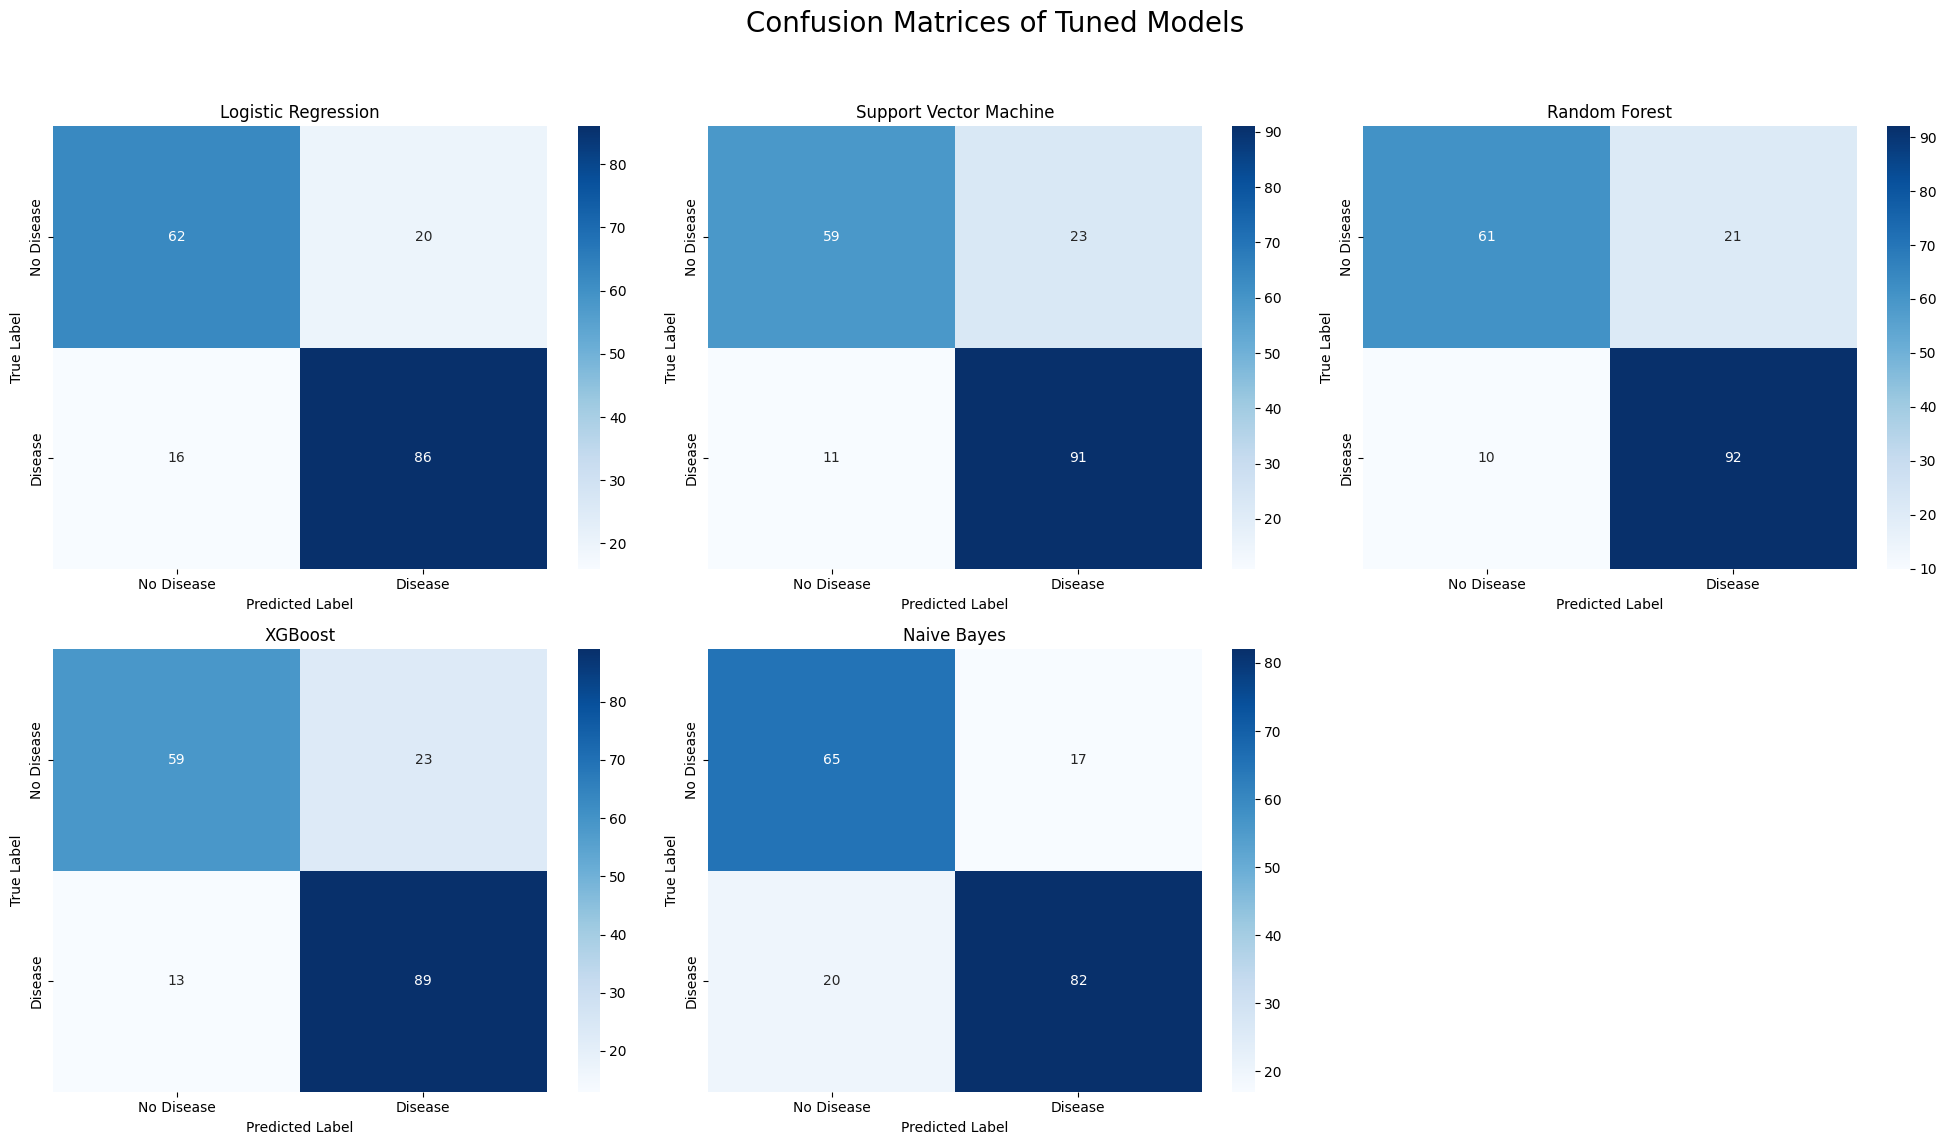

In [11]:
# --- 6. Visualizing Confusion Matrices ---
print("\n--- Visualizing Confusion Matrices for Tuned Models ---")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
fig.suptitle('Confusion Matrices of Tuned Models', fontsize=20)
axes = axes.flatten()

# Adjust layout in case of fewer than 6 models
for i, (name, data) in enumerate(results.items()):
    ax = axes[i]
    sns.heatmap(data['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

# Hide any unused subplots
for i in range(len(results), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [12]:
# --- 7. Export Results to CSV ---

results_csv_path = "../results/model_comparison.csv"
results_df.to_csv(results_csv_path, index=True)
print(f"\nModel comparison results saved to: {results_csv_path}")


Model comparison results saved to: ../results/model_comparison.csv
